# AP 155 Lab Exercise
---
## Exercise 3: Numbers | Horner's method

_Instructions_: 
- **Report discussion:** Address the following prompts.
    - Compare the rounding error patterns and output stability of Horner's method versus the naive power evaluation.
    - Explain why algebraically identical expressions (e.g., the two expressions of polynomials in problem 1, or the three ways we expressed the same function in problem 2) produce different numerical values when implemented in floating-point arithmetic.
    - Discuss how algorithmic redesign (such as Horner's rule or expression restructuring) mitigates floating-point error accumulation.
- **Report figure (to be reflected in code) (Problem 2):** Create a $2 \times 3$ grid of subplots comparing evaluations of the rational function $r(x)$:
    - Columns (3 Methods): Naive method (using direct powers), Horner's method, Rewritten form $s(x)$
    - Rows (2 values of $x$-points) $x= 1.606 + 2^{-52}$ and $2.400 + 2^{-52}i$ where $i\in[0,800]$.
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Domingo, Judiele Fatima P.
- _Student No._: 2023-05167
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Discussion 


In Problem , Horner's method produced more stable results than the naive method. The Horner's method reduces the number of operations and removes high powers of x which eliminates some floating-point rounding errors thus improving stability. In Problem 2, the naive method produced obvious fluctutions while the Horner's method minimized fluctations where diagonal lines are now observable and data points have tighter margins. The rewritten expression, s(x), however has no noticeable fluctuations in x thus having constant values and appearing as a flat line. For floating-point arithmetic, varying sequence of operations or algebraic forms may amplify rounding errors. The naive method amplifies the rounding error due to the accumulation of high powers of x. Horner's method reduces rounding erros by using a nested form of the function. The rewritten function s(x) further simplifies the expression and avoids catastrophic cancellation, providing the most stable result. Thus coming up with algebraically equivalent expressions that 1.) reduces the number of operations and 2.) avoids catastrophic cancellation are necessary.

---

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

This problem discussed error buildup when trying to evaluate polynomials without and with the use of *Horner's Rule*. Take a polynomial of degree $n-1$:
$$ P(x) = p_0 + p_1x + p_2x^2 + p_3x^3 + ... + p_{n-1}x^{n-1}. $$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right.

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x\times x\times ... \times x$ (where there are $i-1$ multiplications). Thus, this way of approaching the problem corresponds to
$$ 1 + 2 + ... + n-2 = \frac{(n-1)(n-2)}{2}$$
multiplications, from $x^2$ all the way up to $x^{n-1}$. 

Let `coeffs=[(-11)**i for i in reversed(range(8))]` and `x = 11.01`

In [2]:
coeffs= [(-11)**i for i in reversed(range(8))] #results in [(-11)^7, (-11)^6, ... , (-11)^0]
x = 11.01

In [3]:
def eval_naive(coeffsList, x):
    """evaluate naively from left to right, using the power/exponent operations"""
    Polynomial_val = 0
    for i, coeff in enumerate(coeffsList):
        Polynomial_val += coeff*x**i #sums all p_n*x^n terms
    return Polynomial_val

eval_naive(coeffs, x)

71056.02362162992

If we write the polynomial: 
$$ P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + ... + x(p_{n-2} + xp_{n-1})...))) \tag{1}$$

then we can get away with only $n-1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree).

Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left.

In [4]:
def eval_horner(coeffsList, x):
    """using Horner's rule from right to left"""
    val = 0
    for coeff in reversed(coeffsList):
        val = val*x+coeff
    return val

eval_horner(coeffs, x)

71056.02362163365

Try timing the code and compare (Shift enter the next two cells)

In [5]:
%timeit eval_horner(coeffs, x)

312 ns ± 4.67 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [6]:
%timeit eval_naive(coeffs, x)

659 ns ± 45 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Apply the previous two functions to the (admittedly artificial) case of:
`coeffs=[(-11)**i for i in reversed(range(8))]` and $x=11.01$. Observe any discrepancy and discuss its origin.

In [7]:
naive_val = eval_naive(coeffs, x)
horner_val = eval_horner(coeffs, x)

print(f"Naive evaluation:   {naive_val}")
print(f"Horner's evaluation: {horner_val}")
error = np.abs(naive_val - horner_val)/np.max([np.abs(naive_val), np.abs(horner_val)])*100
print(f'Error: {error}%') # use absolute error over max value 

'''
Naive evaluation:   71056.02362162992
Horner's evaluation: 71056.02362163365
Error: 5.242750872605424e-12%
'''

Naive evaluation:   71056.02362162992
Horner's evaluation: 71056.02362163365
Error: 5.242750872605424e-12%


"\nNaive evaluation:   71056.02362162992\nHorner's evaluation: 71056.02362163365\nError: 5.242750872605424e-12%\n"


#### Problem 1 Code Summary:
The function eval_naive evaluates the given polynomial term by term starting with the lowest power of x. Eval_horner evaluates the given polynomial starting from the highest power of x in its nested form. This avoids direct computations of high powers of x which should save on processing power and improve stability. It starts with the leading coefficient and multiplies the current value by x then addin the next coefficient. Both functions are applied onto x and coeffs and the results are compared. The relative error is calculated to check stability of each method.  Both functions are timed to demonstrate efficiency of the Horner's method.



### Problem 2:

This problem studies the rational function introduced in the main text, Eq. (2.53).

$$ r(x) = \frac{4x^4 - 59x^3 + 324 x^2 - 751x + 622}{x^4 - 14x^3 + 72x^2 - 151x + 112} \tag{2}$$

(a) Apply Horner’s rule twice (once for the numerator and once for the denominator) to produce two plots, one for $x = 1.606 + 2^{−52}i$ and one for $x = 2.400 + 2^{−52}i$. Your results should look like Fig. 2.3.


- To replicate Figure 2.3, $i$ is an array from 0 to 800 with dtype np.float64
- This means $x$ should be an array as well

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# coeffs written from lowest power
num_coeffs = [622, -751, 324, -59,4]
den_coeffs = [112, -151, 72, -14, 1]

i = np.arange(0,801, dtype=np.float64) #creates an array from 0 to 800 (float 64bits)

x1 = 1.606 + 2**(-52)*i
x2 = 2.400 + 2**(-52)*i

#We will use these variables for the rest of the code below

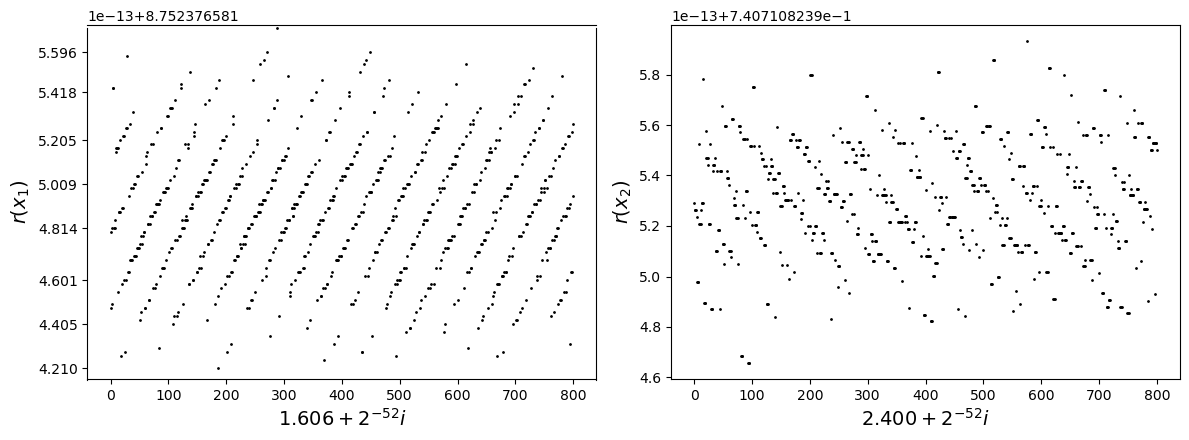

In [9]:
#Applying horner's rule in numerator and denominator
y1 = eval_horner(num_coeffs,x1) / eval_horner(den_coeffs, x1) #evaluating r(x1)
y2 = eval_horner(num_coeffs,x2) / eval_horner(den_coeffs, x2) #evaluating r(x2) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(i, y1, s=1, c='k')
ax1.set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
ax1.set_ylabel(r'$r(x_1)$', fontsize=14)
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.scatter(i, y2, s=1, c='k')
ax2.set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
ax2.set_ylabel(r'$r(x_2)$', fontsize=14)

plt.tight_layout()

#The output should look like figure 3. 
#The y-axis could be confusing the but there's a number on top that ...
#...tells the order of magnitude and the offset of the tick marks on the y-axis

(b) Create a new Python function that codes up the following expression:
$$ s(x)= 4− \frac{3(x−2)[(x−5)^2 + 4]}{x + (x−2)^2[(x−5)^2 + 3]}$$
which is a rewritten version of our rational function. Apply this new function for
the previous two plots and compare the rounding error pattern, size, etc.

In [10]:
def s(x):
    num = 3*(x-2)*[(x-5)**2+4]
    den = x + (x-2)**2*((x-5)**2+3)
    return 4 - num/den

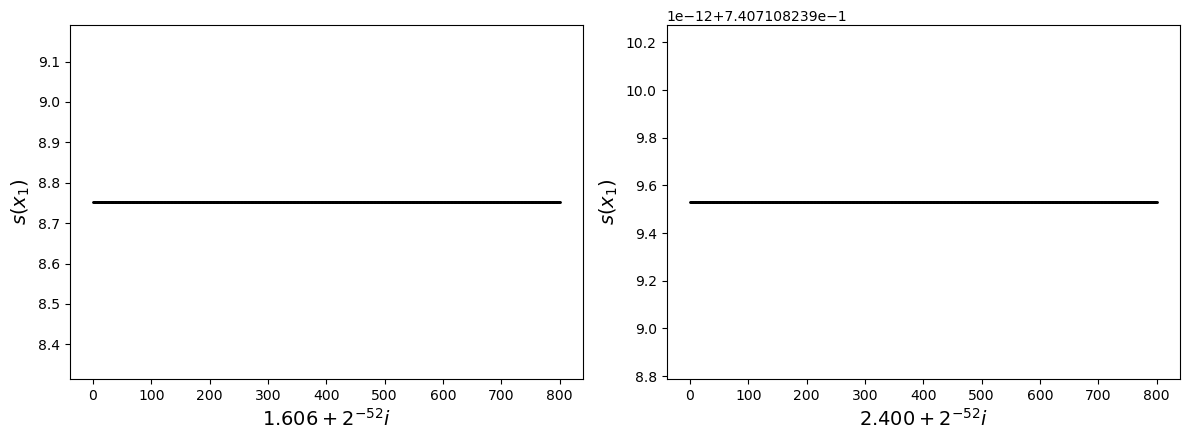

In [11]:

#evaluates s(x) for x1 & x2
y1 = s(x1)
y2 = s(x2)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4.5))

ax1.scatter(i, y1, s=1, c='k')
ax1.set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
ax1.set_ylabel(r'$s(x_1)$', fontsize=14)
ax1.set_ylim(bottom=np.min(y1), top=np.max(y1))

ax2.scatter(i, y2, s=1, c='k')
ax2.set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
ax2.set_ylabel(r'$s(x_1)$', fontsize=14)

plt.tight_layout()

(c) Now introduce two more sets of results, this time for the starting expression for $r(x)$ produced using (not Horner’s rule but) the naive implementation, using powers (i.e., the way you would have coded this up before doing problem 2.11).
Interpret your findings.

- Note: use the earlier function in problem 1 in the naive evaluation

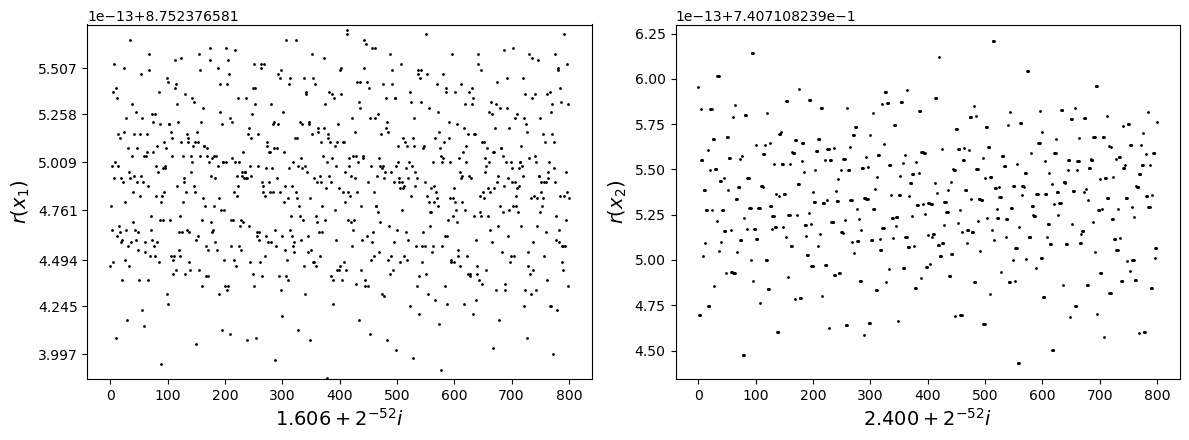

In [12]:
import matplotlib.pyplot as plt
import numpy as np

num_coeffs = [622, -751, 324, -59,4]
den_coeffs = [112, -151, 72, -14, 1]


y1 = eval_naive(num_coeffs,x1) / eval_naive(den_coeffs,x1)
y2 = eval_naive(num_coeffs,x2) / eval_naive(den_coeffs,x2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(i, y1, s=1, c='k')
ax1.set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
ax1.set_ylabel(r'$r(x_1)$', fontsize=14)
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.scatter(i, y2, s=1, c='k')
ax2.set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
ax2.set_ylabel(r'$r(x_2)$', fontsize=14)

plt.tight_layout()

Let's summarize all outputs (6 of them) into a 2 row by 3 column plot

Text(0.5, 0, '$2.400+2^{-52}i$')

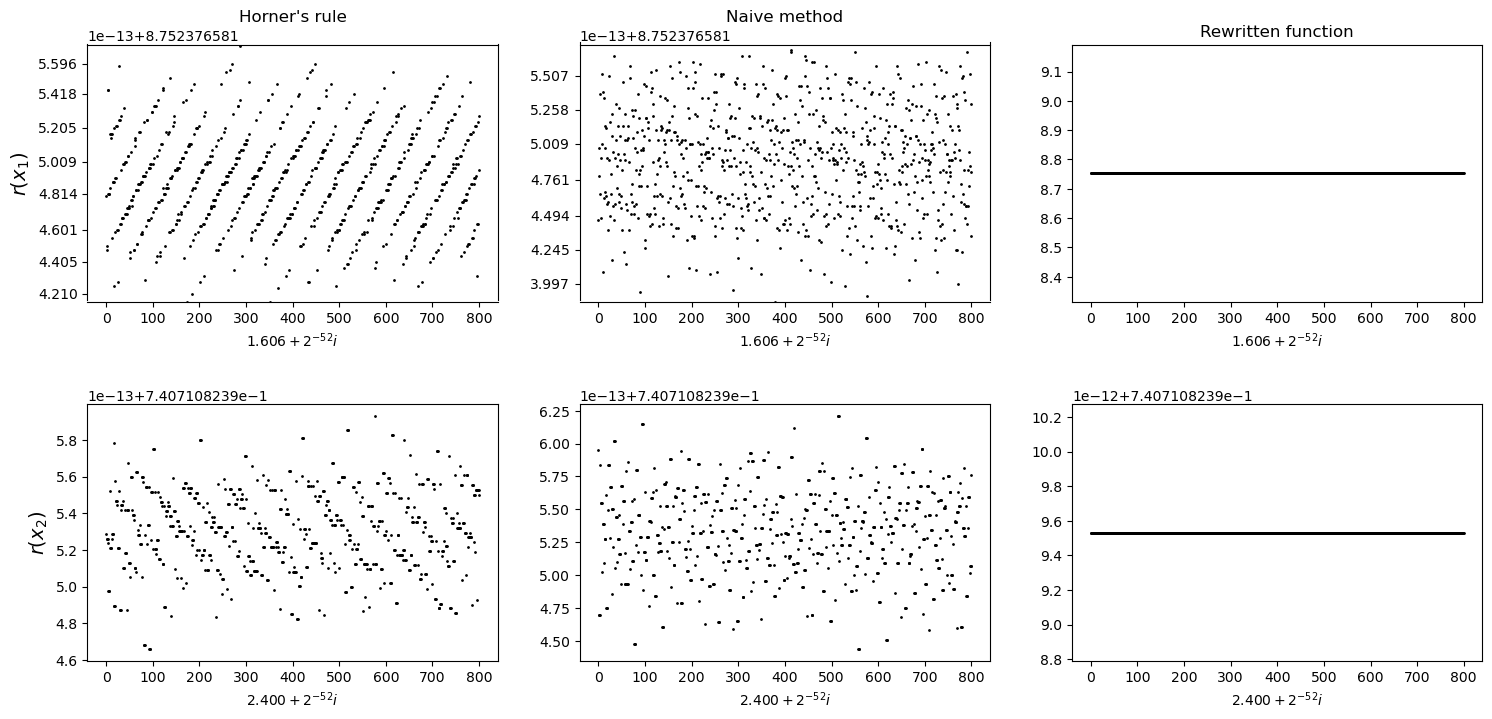

In [13]:
# summarize all subplots

# horner's method for x1 and x2 into r(x)
y_horner_x1 = eval_horner(num_coeffs,x1) / eval_horner(den_coeffs,x1)
y_horner_x2 = eval_horner(num_coeffs,x2) / eval_horner(den_coeffs,x2)

#naive method for x1 and x2 into r(x)
y_naive_x1 = eval_naive(num_coeffs,x1) / eval_naive(den_coeffs,x1) 
y_naive_x2 = eval_naive(num_coeffs,x2) / eval_naive(den_coeffs,x2)

#rewritten expression x1 and x2 into s(x)
y_good_x1 = s(x1)
y_good_x2 = s(x2)
""" 
Causes value error: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (6,) + inhomogeneous part.
arrays = [y_horner_x1, y_naive_x1, y_good_x1, y_horner_x2, y_naive_x2, y_good_x2
y_min = np.min(arrays)
y_max = np.max(arrays)
"""

#fixing value error
y_min = min(np.min(y_horner_x1), np.min(y_horner_x2), np.min(y_naive_x1), np.min(y_naive_x2), np.min(y_good_x1), np.min(y_good_x2))
y_max = max(np.max(y_horner_x1), np.max(y_horner_x2), np.max(y_naive_x1), np.max(y_naive_x2), np.max(y_good_x1), np.max(y_good_x2))

fig, axs = plt.subplots(2, 3, figsize=(6*3, 8))
fig.subplots_adjust(hspace=0.4)

axs[0, 0].scatter(i, y_horner_x1, s=1, c='k')
axs[0, 0].set_ylim(min(y_horner_x1), max(y_horner_x1))
axs[1, 0].scatter(i, y_horner_x2, s=1, c='k')
axs[0, 0].set_title("Horner's rule")
axs[0, 0].set_xlabel(r'$1.606+2^{-52}i$')
axs[1, 0].set_xlabel(r'$2.400+2^{-52}i$')
axs[0, 0].set_ylabel(r'$r(x_1)$', fontsize=14)
axs[1, 0].set_ylabel(r'$r(x_2)$', fontsize=14)


axs[0, 1].scatter(i, y_naive_x1, s=1, c='k')
axs[0, 1].set_ylim(min(y_naive_x1), max(y_naive_x1))
axs[1, 1].scatter(i, y_naive_x2, s=1, c='k')
axs[0, 1].set_title("Naive method")
axs[0, 1].set_xlabel(r'$1.606+2^{-52}i$')
axs[1, 1].set_xlabel(r'$2.400+2^{-52}i$')

axs[0, 2].scatter(i, y_good_x1, s=1, c='k')
axs[0, 2].set_ylim(np.min(y_good_x1), np.max(y_good_x1))
axs[1, 2].scatter(i, y_good_x2, s=1, c='k')
axs[0, 2].set_title("Rewritten function")
axs[0, 2].set_xlabel(r'$1.606+2^{-52}i$')
axs[1, 2].set_xlabel(r'$2.400+2^{-52}i$')


#### Problem 2 code summary

The code evaluates r(x) using 3 methods: Horner's method, naive method, and through s(x), an algebraically equivalent expression. Horner's method is applied twice, once to the numerator and another instance on the denominator, this is then combined into one variable to get r(x). An algebraically equivalent form, s(x), is computed and compared to Horner's method and the naive method. All results are then collected into a singular graph for comparison

---